# 01 · Exploración y Diagnóstico de Datos (EDA)
## Proyecto: Estimador de Capacidad de Pago — Sector Informal (ENIGH 2024)

**Fuente:** `conjunto_de_datos_concentradohogar_enigh2024_ns.csv` — INEGI, ENIGH 2024 Nueva Serie

**Objetivo de este notebook:**
Realizar un diagnóstico completo de la base de datos antes de cualquier modelado:

1. Panorama general (dimensiones, memoria, tipos de dato)
2. Valores nulos
3. Duplicados
4. Cardinalidad (valores únicos por columna)
5. Variables de interés para el proyecto
6. Estadísticas descriptivas
7. Distribuciones (numéricas y categóricas)
8. Construcción y análisis de la variable objetivo (`ing_mensual` / `clase_ingreso`)
9. Detección de valores atípicos (outliers)
10. Correlaciones entre variables numéricas
11. Resumen ejecutivo automático (se guarda en `reports/`)

> Este notebook **no modifica** los datos originales: solo lee, diagnostica y
> genera reportes/figuras en `reports/`. La limpieza y el feature engineering
> se realizan en el notebook `02_preprocesamiento_feature_engineering.ipynb`.


## 0. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Estilo de gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Rutas del proyecto (relativas a notebooks/)
PROJECT_ROOT = Path("..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"

FIGURES.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_RAW / "conjunto_de_datos_concentradohogar_enigh2024_ns.csv"
DATA_FILE


WindowsPath('../data/raw/conjunto_de_datos_concentradohogar_enigh2024_ns.csv')

In [2]:
# Columnas que son CÓDIGOS DE CATÁLOGO y deben leerse como texto
# (para no perder ceros a la izquierda ni interpretarlas como números)
DTYPE_CATALOGOS = {
    "folioviv": str,
    "foliohog": str,
    "ubica_geo": str,
    "tam_loc": str,
    "est_socio": str,
    "est_dis": str,
    "upm": str,
    "clase_hog": str,
    "sexo_jefe": str,
    "educa_jefe": str,
}

df = pd.read_csv(DATA_FILE, dtype=DTYPE_CATALOGOS)
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 91,414  |  Columnas: 126


,folioviv,foliohog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,clase_hog,sexo_jefe,...,mater_serv,material,servicio,deposito,prest_terc,pago_tarje,deudas,balance,otras_erog,smg
0,0100001901,1,01001,1,3,001,0000001,207,2,1,...,0.00,0.00,0.0,21365.21,0.00,0.00,8217.39,0.0,0.00,22403.7
1,0100001902,1,01001,1,3,001,0000001,207,2,1,...,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,22403.7
2,0100001904,1,01001,1,3,001,0000001,207,2,2,...,0.00,0.00,0.0,4695.65,0.00,0.00,0.00,0.0,0.00,22403.7
3,0100001905,1,01001,1,3,001,0000001,207,2,1,...,366.84,366.84,0.0,5869.56,0.00,7336.95,2934.78,0.0,6260.86,22403.7
4,0100002501,1,01001,1,2,002,0000002,196,2,2,...,0.00,0.00,0.0,0.00,2934.78,0.00,0.00,0.0,7113.91,22403.7


## 1. Panorama general del dataset

Dimensiones, uso de memoria y tipos de dato generales.

In [3]:
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Uso de memoria total: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("Conteo de columnas por tipo de dato:")
print(df.dtypes.value_counts())

Dimensiones: 91,414 filas x 126 columnas
Uso de memoria total: 126.41 MB

Conteo de columnas por tipo de dato:
float64    104
int64       12
object      10
Name: count, dtype: int64


In [4]:
# Tabla resumen de tipos de dato por columna
dtypes_df = pd.DataFrame({
    "columna": df.columns,
    "dtype": df.dtypes.astype(str).values
})
dtypes_df["dtype"].value_counts()

dtype
float64    104
int64       12
object      10
Name: count, dtype: int64

## 2. Valores nulos

Conteo y porcentaje de valores faltantes por columna. Solo se muestran
columnas con al menos un nulo (si la tabla sale vacía, el dataset no tiene
valores faltantes).

In [ ]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

reporte_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "pct_nulos": pct_nulos
})
reporte_nulos = reporte_nulos[reporte_nulos["n_nulos"] > 0].sort_values(
    "n_nulos", ascending=False
)

if reporte_nulos.empty:
    print("No se encontraron valores nulos en ninguna columna.")
else:
    print(f"{len(reporte_nulos)} columnas con valores nulos:")
    display(reporte_nulos)

✅ No se encontraron valores nulos en ninguna columna.


## 3. Duplicados

Se revisan dos casos:

- **Filas completamente duplicadas** (todas las columnas idénticas).
- **Duplicados por identificador de hogar** (`folioviv` + `foliohog`), que
  debería ser único — cada combinación identifica un hogar específico.

In [6]:
dup_filas = df.duplicated().sum()
print(f"Filas completamente duplicadas: {dup_filas:,}")

if {"folioviv", "foliohog"}.issubset(df.columns):
    dup_hogar = df.duplicated(subset=["folioviv", "foliohog"]).sum()
    print(f"Duplicados por (folioviv, foliohog): {dup_hogar:,}")
    if dup_hogar > 0:
        display(df[df.duplicated(subset=["folioviv", "foliohog"], keep=False)]
                .sort_values(["folioviv", "foliohog"]).head(10))

Filas completamente duplicadas: 0
Duplicados por (folioviv, foliohog): 0


## 4. Cardinalidad: número de valores únicos por columna

Útil para distinguir variables categóricas (pocos valores únicos) de
variables continuas (muchos valores únicos), y para detectar columnas
constantes (1 solo valor, no aportan información).

In [7]:
cardinalidad = df.nunique().sort_values()
cardinalidad_df = cardinalidad.reset_index()
cardinalidad_df.columns = ["columna", "n_valores_unicos"]

print("Columnas con un solo valor único (constantes):")
display(cardinalidad_df[cardinalidad_df["n_valores_unicos"] == 1])

print("\nTop 15 columnas con MENOR cardinalidad (candidatas a categóricas):")
display(cardinalidad_df.head(15))

print("\nTop 10 columnas con MAYOR cardinalidad (candidatas a continuas):")
display(cardinalidad_df.tail(10))

Columnas con un solo valor único (constantes):


,columna,n_valores_unicos
0,smg,1



Top 15 columnas con MENOR cardinalidad (candidatas a categóricas):


,columna,n_valores_unicos
0,smg,1
1,sexo_jefe,2
2,foliohog,4
3,tam_loc,4
4,est_socio,4
5,clase_hog,5
6,p65mas,6
7,menores,10
8,educa_jefe,11
9,perc_ocupa,12



Top 10 columnas con MAYOR cardinalidad (candidatas a continuas):


,columna,n_valores_unicos
116,trabajo,36539
117,ali_dentro,45352
118,limpieza,46038
119,alimentos,51451
120,ingtrab,52460
121,personales,53352
122,transporte,56986
123,ing_cor,84680
124,folioviv,90324
125,gasto_mon,90830


## 5. Variables de interés para el proyecto

Subconjunto de variables relevantes según el diseño del proyecto
(target + predictoras sociodemográficas). Trabajamos con esta selección
para el resto del EDA, sin perder de vista el panorama general ya revisado.

In [8]:
VARS_TARGET = ["ing_cor"]

VARS_PREDICTORAS = [
    "ubica_geo",
    "tam_loc",
    "est_socio",
    "clase_hog",
    "sexo_jefe",
    "edad_jefe",
    "educa_jefe",
    "tot_integ",
    "ocupados",
    "factor",  # factor de expansión, se usa para ponderar el EDA (no como predictor)
]

VARS_INTERES = VARS_TARGET + VARS_PREDICTORAS

df_interes = df[VARS_INTERES].copy()
df_interes.head()

,ing_cor,ubica_geo,tam_loc,est_socio,clase_hog,sexo_jefe,edad_jefe,educa_jefe,tot_integ,ocupados,factor
0,138232.38,01001,1,3,2,1,32,06,4,2,207
1,118014.04,01001,1,3,2,1,48,09,4,2,207
2,46866.32,01001,1,3,2,2,60,06,2,2,207
3,110430.10,01001,1,3,2,1,43,08,4,3,207
4,99494.12,01001,1,2,2,2,29,08,4,2,196


In [9]:
# Tipos y cardinalidad solo de las variables de interés
resumen_interes = pd.DataFrame({
    "dtype": df_interes.dtypes.astype(str),
    "n_nulos": df_interes.isnull().sum(),
    "pct_nulos": (df_interes.isnull().mean() * 100).round(2),
    "n_unicos": df_interes.nunique(),
})
resumen_interes

,dtype,n_nulos,pct_nulos,n_unicos
ing_cor,float64,0,0.0,84680
ubica_geo,object,0,0.0,1112
tam_loc,object,0,0.0,4
est_socio,object,0,0.0,4
clase_hog,object,0,0.0,5
sexo_jefe,object,0,0.0,2
edad_jefe,int64,0,0.0,91
educa_jefe,object,0,0.0,11
tot_integ,int64,0,0.0,19
ocupados,int64,0,0.0,12


## 6. Estadísticas descriptivas

Separadas en variables numéricas continuas y variables categóricas
(códigos de catálogo).

In [10]:
VARS_NUM = ["ing_cor", "edad_jefe", "tot_integ", "ocupados", "factor"]
VARS_CAT = ["ubica_geo", "tam_loc", "est_socio", "clase_hog", "sexo_jefe", "educa_jefe"]

print("Estadísticas descriptivas — variables numéricas")
display(df_interes[VARS_NUM].describe().T)

Estadísticas descriptivas — variables numéricas


,count,mean,std,min,25%,50%,75%,max
ing_cor,91414.0,72273.586289,93876.588278,0.0,34520.8725,55666.18,88840.7325,17431977.54
edad_jefe,91414.0,51.537281,15.994928,14.0,39.0000,51.00,63.0000,106.00
tot_integ,91414.0,3.374439,1.754476,1.0,2.0000,3.00,4.0000,20.00
ocupados,91414.0,1.632967,1.081635,0.0,1.0000,1.00,2.0000,13.00
factor,91414.0,424.773339,474.677171,4.0,141.0000,288.00,526.0000,7127.00


In [11]:
print("Frecuencias — variables categóricas (top categorías)")
for col in VARS_CAT:
    print(f"\n--- {col} ({df_interes[col].nunique()} categorías únicas) ---")
    display(df_interes[col].value_counts(normalize=True).mul(100).round(2)
            .head(10).rename("porcentaje (%)"))

Frecuencias — variables categóricas (top categorías)

--- ubica_geo (1112 categorías únicas) ---


ubica_geo
01001    1.85
02002    1.59
08037    1.50
25006    1.27
03003    1.23
02004    1.17
23005    1.16
22014    1.14
05030    1.01
06007    1.01
Name: porcentaje (%), dtype: float64


--- tam_loc (4 categorías únicas) ---


tam_loc
4    39.19
1    37.53
3    11.85
2    11.43
Name: porcentaje (%), dtype: float64


--- est_socio (4 categorías únicas) ---


...

clase_hog
2    61.74
3    23.59
1    13.70
4     0.62
5     0.35
Name: porcentaje (%), dtype: float64


--- sexo_jefe (2 categorías únicas) ---


sexo_jefe
1    67.66
2    32.34
Name: porcentaje (%), dtype: float64


--- educa_jefe (11 categorías únicas) ---


educa_jefe
06    27.22
04    16.30
03    14.11
08    13.90
10    11.13
01     5.92
09     3.18
07     3.07
05     2.93
11     2.22
Name: porcentaje (%), dtype: float64

## 7. Distribuciones

### 7.1 Variables numéricas continuas (histogramas + boxplots)

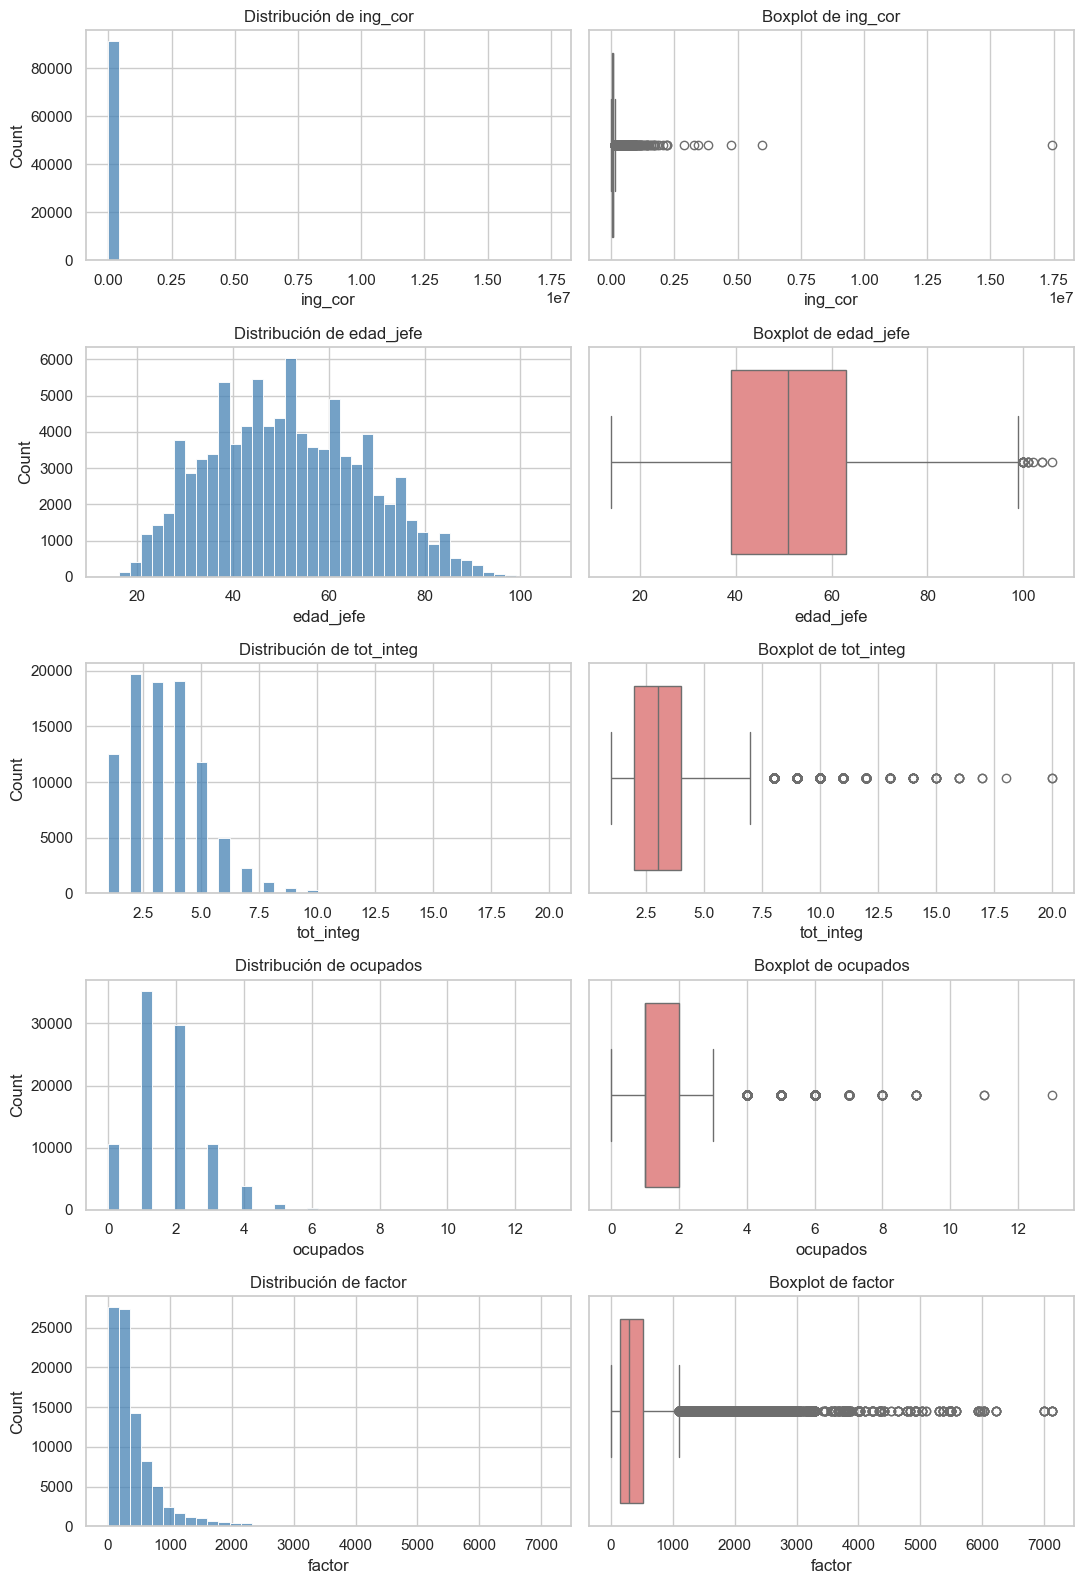

In [12]:
fig, axes = plt.subplots(len(VARS_NUM), 2, figsize=(11, 3.2 * len(VARS_NUM)))

for i, col in enumerate(VARS_NUM):
    sns.histplot(df_interes[col], bins=40, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"Distribución de {col}")

    sns.boxplot(x=df_interes[col], ax=axes[i, 1], color="lightcoral")
    axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.savefig(FIGURES / "01_distribuciones_numericas.png", dpi=120, bbox_inches="tight")
plt.show()

### 7.2 Variables categóricas (gráficas de barras)

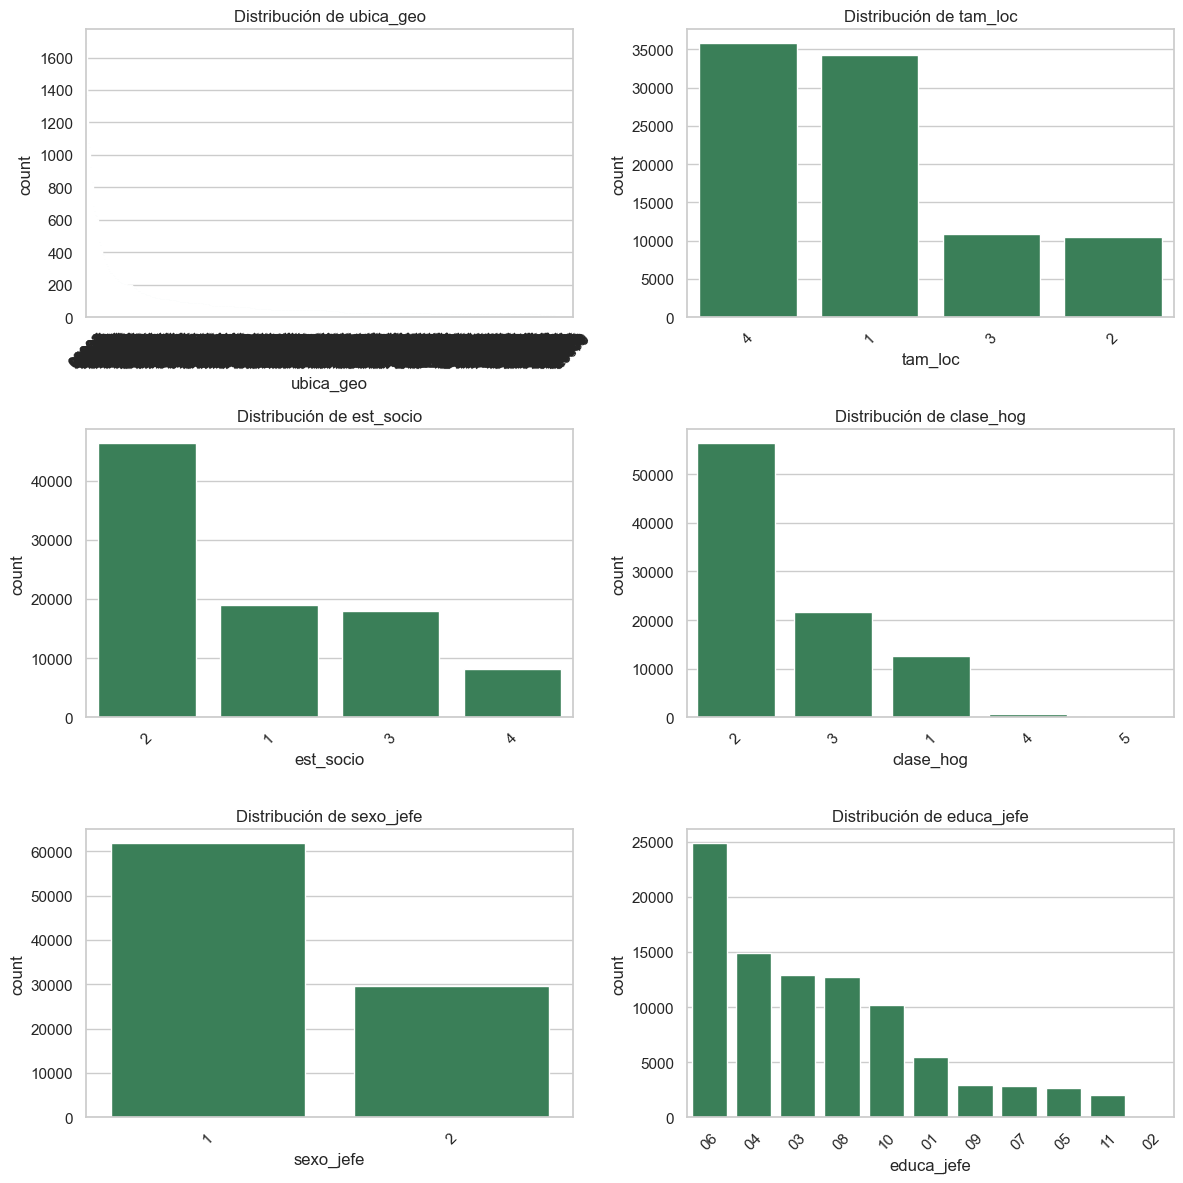

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(VARS_CAT):
    orden = df_interes[col].value_counts().index
    sns.countplot(data=df_interes, x=col, order=orden, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(FIGURES / "02_distribuciones_categoricas.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Variable objetivo: `ing_cor` → ingreso mensual y `clase_ingreso`

`ing_cor` es el **ingreso corriente trimestral** del hogar. Para trabajar con
una magnitud mensual (más interpretable y comparable con un "ingreso
mensual" de referencia), se calcula:

$$ \text{ing\_mensual} = \frac{\text{ing\_cor}}{3} $$

Posteriormente se evalúan distintos posibles **umbrales de clasificación**
(percentiles, $15{,}000 MXN, y la mediana) para definir la variable binaria
`clase_ingreso`.

In [14]:
df_interes["ing_mensual"] = df_interes["ing_cor"] / 3

print("Estadísticas descriptivas de ing_mensual (MXN):")
display(df_interes["ing_mensual"].describe().round(2))

print("\nPercentiles clave:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p}: {np.percentile(df_interes['ing_mensual'], p):,.2f}")

Estadísticas descriptivas de ing_mensual (MXN):


count      91414.00
mean       24091.20
std        31292.20
min            0.00
25%        11506.96
50%        18555.39
75%        29613.58
max      5810659.18
Name: ing_mensual, dtype: float64


Percentiles clave:
  P10: 7,325.66
  P25: 11,506.96
  P50: 18,555.39
  P75: 29,613.58
  P90: 45,221.60
  P95: 58,415.21
  P99: 103,257.29


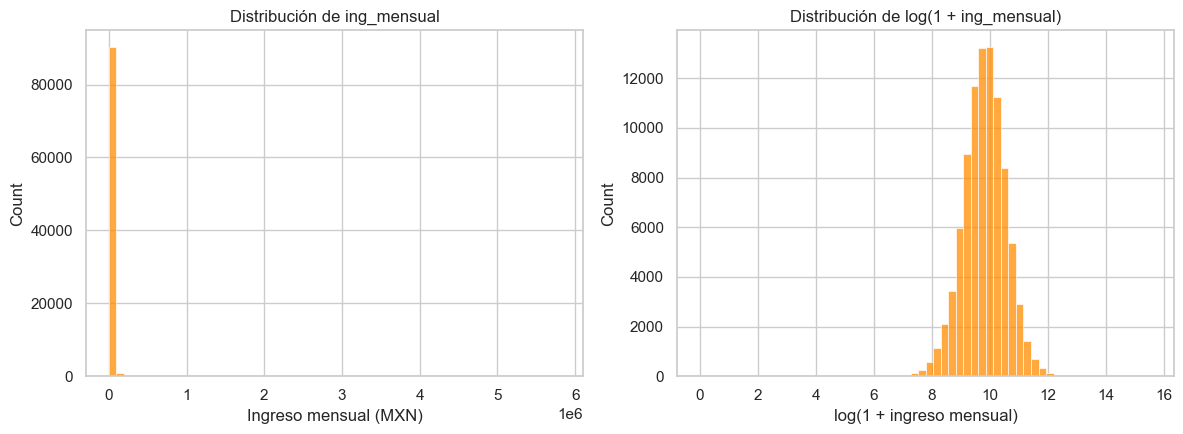

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df_interes["ing_mensual"], bins=60, ax=axes[0], color="darkorange")
axes[0].set_title("Distribución de ing_mensual")
axes[0].set_xlabel("Ingreso mensual (MXN)")

# Versión con escala log para visualizar mejor la cola derecha
sns.histplot(np.log1p(df_interes["ing_mensual"]), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de log(1 + ing_mensual)")
axes[1].set_xlabel("log(1 + ingreso mensual)")

plt.tight_layout()
plt.savefig(FIGURES / "03_distribucion_ingreso_mensual.png", dpi=120, bbox_inches="tight")
plt.show()

In [16]:
# Comparación de balance de clases para distintos umbrales candidatos
UMBRALES = {
    "Mediana": df_interes["ing_mensual"].median(),
    "15,000 MXN (umbral propuesto en README)": 15000,
    "Percentil 60": np.percentile(df_interes["ing_mensual"], 60),
    "Percentil 75": np.percentile(df_interes["ing_mensual"], 75),
}

balance = []
for nombre, umbral in UMBRALES.items():
    clase = (df_interes["ing_mensual"] >= umbral).astype(int)
    balance.append({
        "umbral": nombre,
        "valor_umbral": round(umbral, 2),
        "pct_clase_0 (< umbral)": round((clase == 0).mean() * 100, 2),
        "pct_clase_1 (>= umbral)": round((clase == 1).mean() * 100, 2),
    })

pd.DataFrame(balance)

,umbral,valor_umbral,pct_clase_0 (< umbral),pct_clase_1 (>= umbral)
0,Mediana,18555.39,49.99,50.01
1,"15,000 MXN (umbral propuesto en README)",15000.00,38.14,61.86
2,Percentil 60,22134.39,60.00,40.00
3,Percentil 75,29613.58,75.00,25.00


## 9. Detección de valores atípicos (outliers)

Se aplica el criterio de rango intercuartílico (IQR): un valor se considera
atípico si está fuera de $[Q1 - 1.5 \cdot IQR,\; Q3 + 1.5 \cdot IQR]$.

> Nota: en variables de ingreso/gasto es normal tener una cola derecha larga
> (hogares de altos ingresos). No implica necesariamente un error de
> captura, pero conviene cuantificarlo antes de decidir si se recortan,
> transforman (log) o se dejan tal cual.

In [17]:
def resumen_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return {
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "limite_inferior": round(lim_inf, 2),
        "limite_superior": round(lim_sup, 2),
        "n_outliers": int(n_outliers),
        "pct_outliers": round(n_outliers / len(serie) * 100, 2),
    }

outliers_resumen = pd.DataFrame({
    col: resumen_outliers_iqr(df_interes[col])
    for col in ["ing_mensual", "edad_jefe", "tot_integ", "ocupados"]
}).T

outliers_resumen

,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
ing_mensual,11506.96,29613.58,18106.62,-15652.97,56773.51,4959.0,5.42
edad_jefe,39.00,63.00,24.00,3.00,99.00,20.0,0.02
tot_integ,2.00,4.00,2.00,-1.00,7.00,2040.0,2.23
ocupados,1.00,2.00,1.00,-0.50,3.50,5149.0,5.63


## 10. Correlaciones entre variables numéricas

Matriz de correlación (Pearson) entre las variables numéricas de interés,
incluyendo el ingreso mensual.

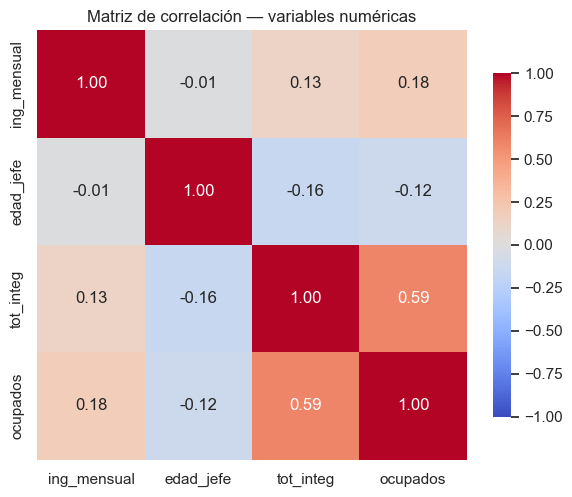

In [18]:
corr_vars = ["ing_mensual", "edad_jefe", "tot_integ", "ocupados"]
corr_matrix = df_interes[corr_vars].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.savefig(FIGURES / "04_matriz_correlacion.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Resumen ejecutivo automático

Se genera un reporte en Markdown (`reports/resumen_eda.md`) con los
principales hallazgos del diagnóstico, para usarlo como referencia rápida o
como insumo para la sección de METODOLOGÍA / RESULTADOS del artículo.

In [ ]:
resumen_md = []
resumen_md.append("# Resumen Ejecutivo — EDA `concentradohogar` ENIGH 2024\n")

resumen_md.append("## Panorama general")
resumen_md.append(f"- Filas: {df.shape[0]:,}")
resumen_md.append(f"- Columnas totales: {df.shape[1]}")
resumen_md.append(f"- Memoria total: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
resumen_md.append(f"- Filas completamente duplicadas: {dup_filas:,}")
if {'folioviv', 'foliohog'}.issubset(df.columns):
    resumen_md.append(f"- Duplicados por (folioviv, foliohog): {dup_hogar:,}")

resumen_md.append("\n## Valores nulos (variables de interés)")
nulos_interes = df_interes.isnull().sum()
if nulos_interes.sum() == 0:
    resumen_md.append("- Sin valores nulos en las variables de interés.")
else:
    for col, n in nulos_interes[nulos_interes > 0].items():
        resumen_md.append(f"- `{col}`: {n} nulos ({n/len(df_interes)*100:.2f}%)")

resumen_md.append("\n## Variable objetivo (ing_mensual)")
desc = df_interes["ing_mensual"].describe()
resumen_md.append(f"- Media: {desc['mean']:,.2f} MXN")
resumen_md.append(f"- Mediana: {desc['50%']:,.2f} MXN")
resumen_md.append(f"- Desviación estándar: {desc['std']:,.2f} MXN")
resumen_md.append(f"- Mínimo: {desc['min']:,.2f} MXN")
resumen_md.append(f"- Máximo: {desc['max']:,.2f} MXN")

resumen_md.append("\n## Balance de clases por umbral candidato")
resumen_md.append(pd.DataFrame(balance).to_markdown(index=False))

resumen_md.append("\n## Outliers (criterio IQR)")
resumen_md.append(outliers_resumen.to_markdown())

resumen_md.append("\n## Cardinalidad de variables categóricas")
for col in VARS_CAT:
    resumen_md.append(f"- `{col}`: {df_interes[col].nunique()} categorías")

texto_resumen = "\n".join(resumen_md)

with open(REPORTS / "resumen_eda.md", "w", encoding="utf-8") as f:
    f.write(texto_resumen)

print(" Resumen guardado en reports/resumen_eda.md")
print("\n" + "=" * 60)
print(texto_resumen)

Resumen guardado en reports/resumen_eda.md

# Resumen Ejecutivo — EDA `concentradohogar` ENIGH 2024

## Panorama general
- Filas: 91,414
- Columnas totales: 126
- Memoria total: 126.41 MB
- Filas completamente duplicadas: 0
- Duplicados por (folioviv, foliohog): 0

## Valores nulos (variables de interés)
- Sin valores nulos en las variables de interés.

## Variable objetivo (ing_mensual)
- Media: 24,091.20 MXN
- Mediana: 18,555.39 MXN
- Desviación estándar: 31,292.20 MXN
- Mínimo: 0.00 MXN
- Máximo: 5,810,659.18 MXN

## Balance de clases por umbral candidato
| umbral                                  |   valor_umbral |   pct_clase_0 (< umbral) |   pct_clase_1 (>= umbral) |
|:----------------------------------------|---------------:|-------------------------:|--------------------------:|
| Mediana                                 |        18555.4 |                    49.99 |                     50.01 |
| 15,000 MXN (umbral propuesto en README) |        15000   |                    38.14 |

## Conclusiones del EDA y siguientes pasos

A partir de este diagnóstico, se documentan aquí las decisiones que se
tomarán en el notebook `02_preprocesamiento_feature_engineering.ipynb`:

- **Tratamiento de nulos:** _(completar según resultados — usualmente
  `concentradohogar` no presenta nulos en estas variables, pero se deja
  documentado el resultado real)._
- **Duplicados:** _(completar según resultados)._
- **Umbral de la variable objetivo:** _(elegir y justificar entre mediana,
  $15,000 MXN, percentil 60/75, etc., según el balance de clases obtenido)._
- **Outliers:** _(decidir si se aplican transformaciones, capping, o se
  dejan sin modificar, según el contexto de ingresos)._
- **Variables candidatas confirmadas:** `ubica_geo`, `tam_loc`, `est_socio`
  (a discutir), `clase_hog`, `sexo_jefe`, `edad_jefe`, `educa_jefe`,
  `tot_integ`/`ocupados` (para tasa de dependencia).
